<a href="https://colab.research.google.com/github/TrungCun/speaker_recognition/blob/main/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speaker Recognition Pre-trained Model

**Author:** [TRUNG_GIAP](https://github.com/TrungCun)<br>
**Description:** The training model extracts embedding vectors of 128 dimensions using Mel Frequency Cepstral Coefficients (MFCC).

## Introduction

This example demonstrates how to create a model to classify speakers obtained via Mel Frequency Cepstral Coefficients (MFCC).

It shows the following:

- How to use `librosa` to load, preprocess and feed audio streams into a model.
- How to create a 2D convolutional network for audio classification.

Our process:

- We prepare a dataset of speech samples from different speakers, with the speaker as label.
- We take the MFCC of these samples.
- We train a 2D convnet to predict the correct speaker given a speech sample and extract the embedding vector in the last layer `Activation`.

Get the data from [AudioMNIST](https://github.com/soerenab/AudioMNIST)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls drive/MyDrive/dataset

audio_digit.zip  AudioMNIST.zip  FSDD.zip  noise.zip


In [ ]:
!unzip drive/MyDrive/dataset/AudioMNIST.zip

Streaming output truncated to the last 5000 lines.
  inflating: AudioMNIST/data/51/0_51_17.wav  
  inflating: AudioMNIST/data/51/0_51_18.wav  
  inflating: AudioMNIST/data/51/0_51_19.wav  
  inflating: AudioMNIST/data/51/0_51_2.wav  
  inflating: AudioMNIST/data/51/0_51_20.wav  
  inflating: AudioMNIST/data/51/0_51_21.wav  
  inflating: AudioMNIST/data/51/0_51_22.wav  
  inflating: AudioMNIST/data/51/0_51_23.wav  
  inflating: AudioMNIST/data/51/0_51_24.wav  
  inflating: AudioMNIST/data/51/0_51_25.wav  
  inflating: AudioMNIST/data/51/0_51_26.wav  
  inflating: AudioMNIST/data/51/0_51_27.wav  
  inflating: AudioMNIST/data/51/0_51_28.wav  
  inflating: AudioMNIST/data/51/0_51_29.wav  
  inflating: AudioMNIST/data/51/0_51_3.wav  
  inflating: AudioMNIST/data/51/0_51_30.wav  
  inflating: AudioMNIST/data/51/0_51_31.wav  
  inflating: AudioMNIST/data/51/0_51_32.wav  
  inflating: AudioMNIST/data/51/0_51_33.wav  
  inflating: AudioMNIST/data/51/0_51_34.wav  
  inflating: AudioMNIST/data/51

## Setup

In [ ]:
import os
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as ipd

import keras
from keras.models import Model
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Input, BatchNormalization, Activation, Dropout
from keras.utils import to_categorical

In [ ]:
AUDIO_PATH = '/content/AudioMNIST/data/'

# The sampling rate to use.
# This is the one used in all the audio samples.
SAMPLING_RATE = 8000

# Percentage of samples to use for validation
VALID_SPLIT = 0.1

# Parameter of MFCC
N_MFCC = 13
MAX_LEN = 20
N_FFT = 512

EPOCHS = 100 # For a real training run, use EPOCHS = 100


labels = os.listdir(AUDIO_PATH)
num_classes = len(labels)

## Data preparation

The dataset is composed of 60 folders for 60 different speakers. Each folder contains 500 audio files.
- This origin file in the folder has been sampled at 48000 Hz.
- You need convert frequency down to 8000 Hz for fit with source code.
- You can use any method to change frequency, or use my available source code.
- More information about this dataset is in `audioMNIST_meta.txt`.

we have the following directory structure:
```
data/
...speaker_01/
...speaker_02/
...speaker_03/
...speaker_../
...speaker_60/
...audioMNIST_meta.txt
```

## Dataset processing

In [ ]:
def wav2mfcc(file_path, n_mfcc=N_MFCC, max_len=MAX_LEN):
    wave, sr = librosa.load(file_path, mono=True, sr=None)
    mfcc = librosa.feature.mfcc(y = wave, sr=SAMPLING_RATE, n_mfcc=n_mfcc, n_fft=N_FFT)
    if (max_len > mfcc.shape[1]):
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

# mfcc = wav2mfcc(AUDIO_PATH +'01/0_01_0.wav')
# print(mfcc)
# plt.imshow(wav2mfcc(AUDIO_PATH +'01/4_01_10.wav'))
# pd.DataFrame(wav2mfcc(AUDIO_PATH +'01/0_01_0.wav'))

In [ ]:
from sklearn.model_selection import train_test_split

def get_train_test(valid_split, random_state = 42):
  mfcc_vectors = []
  y = []
  for i, label in enumerate(labels):
    LABEL_PATH = AUDIO_PATH + label + '/'
    for wavfile in os.listdir(LABEL_PATH):
      FILE_PATH = LABEL_PATH + wavfile
      mfcc = wav2mfcc(FILE_PATH)
      mfcc_vectors.append(mfcc)
      y.append(i)
  return train_test_split(mfcc_vectors, y, valid_size = valid_split, random_state = random_state, shuffle = True)

# Split into training and testing
mfcc_train, mfcc_valid, labels_train, labels_valid = get_train_test(VALID_SPLIT)

mfcc_train = np.array(mfcc_train)
mfcc_valid = np.array(mfcc_valid)

# convert labels to binary class matrix
labels_train_hot = to_categorical(labels_train)
labels_valid_hot = to_categorical(labels_valid)

## Model Definition

INPUT -> [[CONV -> RELU]*N -> POOL?]*M -> [FC -> RELU]*K -> FC

In [ ]:
def build_model(input_shape, num_classes):
    input = Input(shape=input_shape, name = 'input')
    x = Conv2D(32, (3,3), padding="same")(input)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.2)(x)

    x = Conv2D(32*2, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.2)(x)

    x = Flatten()(x)
    x = Dense(128)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    output = Dense(num_classes, activation='softmax', name = 'output')(x)

    return Model(input, output)

model = build_model((N_MFCC, MAX_LEN, 1), num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 13, 20, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 13, 20, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 13, 20, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 13, 20, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 6, 10, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6, 10, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 6, 10, 64)           │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 6, 10, 64)           │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 6, 10, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 3, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 3, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 960)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         123,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 60)                  │           7,740 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 150,460 (587.73 KB)

 Trainable params: 150,012 (585.98 KB)

 Non-trainable params: 448 (1.75 KB)

## Training

In [ ]:
model_save_filename = "model_04_04_mfcc_13_20_512_02block_model_final_final.keras"

# Compile the model using Adam's default learning rate
model.compile(loss="categorical_crossentropy",
                  optimizer="adam",
                  metrics=['accuracy'])

# Add callbacks:
#   'EarlyStopping' to stop training when the model is not enhancing anymore
#   'ModelCheckPoint' to always keep the model that has the best val_accuracy
earlystopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
mdlcheckpoint_cb = keras.callbacks.ModelCheckpoint(
    model_save_filename, monitor="val_accuracy", save_best_only=True
)

model.fit(mfcc_train, labels_train_hot, epochs=EPOCHS, validation_data=(mfcc_valid, labels_valid_hot), callbacks=[earlystopping_cb, mdlcheckpoint_cb])

Epoch 1/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.1533 - loss: 3.4795 - val_accuracy: 0.5883 - val_loss: 1.5522
Epoch 2/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5735 - loss: 1.5426 - val_accuracy: 0.7913 - val_loss: 0.7810
Epoch 3/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7118 - loss: 1.0035 - val_accuracy: 0.8270 - val_loss: 0.6181
Epoch 4/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7802 - loss: 0.7475 - val_accuracy: 0.9060 - val_loss: 0.3588
Epoch 5/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8189 - loss: 0.6021 - val_accuracy: 0.9293 - val_loss: 0.2785
Epoch 6/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8533 - loss: 0.4961 - val_accuracy: 0.9357 - val_loss: 0.2430
Epoch 7/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8645 - loss: 0.4552 - val_accuracy: 0.9400 - val_loss: 0.2272
Epoch 8/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8766 - loss: 0.4083 - val_ac

## Evaluation

In [ ]:
score = model.evaluate(mfcc_valid, labels_valid_hot, verbose=0)
print(f'Test loss: {score[0]} / Test accuracy: {score[1]}')

Test loss: 0.0790461003780365 / Test accuracy: 0.9779999852180481


## Confusion Matrix

In [ ]:
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(15, 15))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=30)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=15)
    plt.yticks(tick_marks, classes, fontsize=15)

    fmt = '.3f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), size=11,
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label', fontsize=30)
    plt.xlabel('Predicted label', fontsize=30)
    plt.savefig('picConfMatrix.png', dpi=400)
    plt.tight_layout()

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Confusion matrix, without normalization


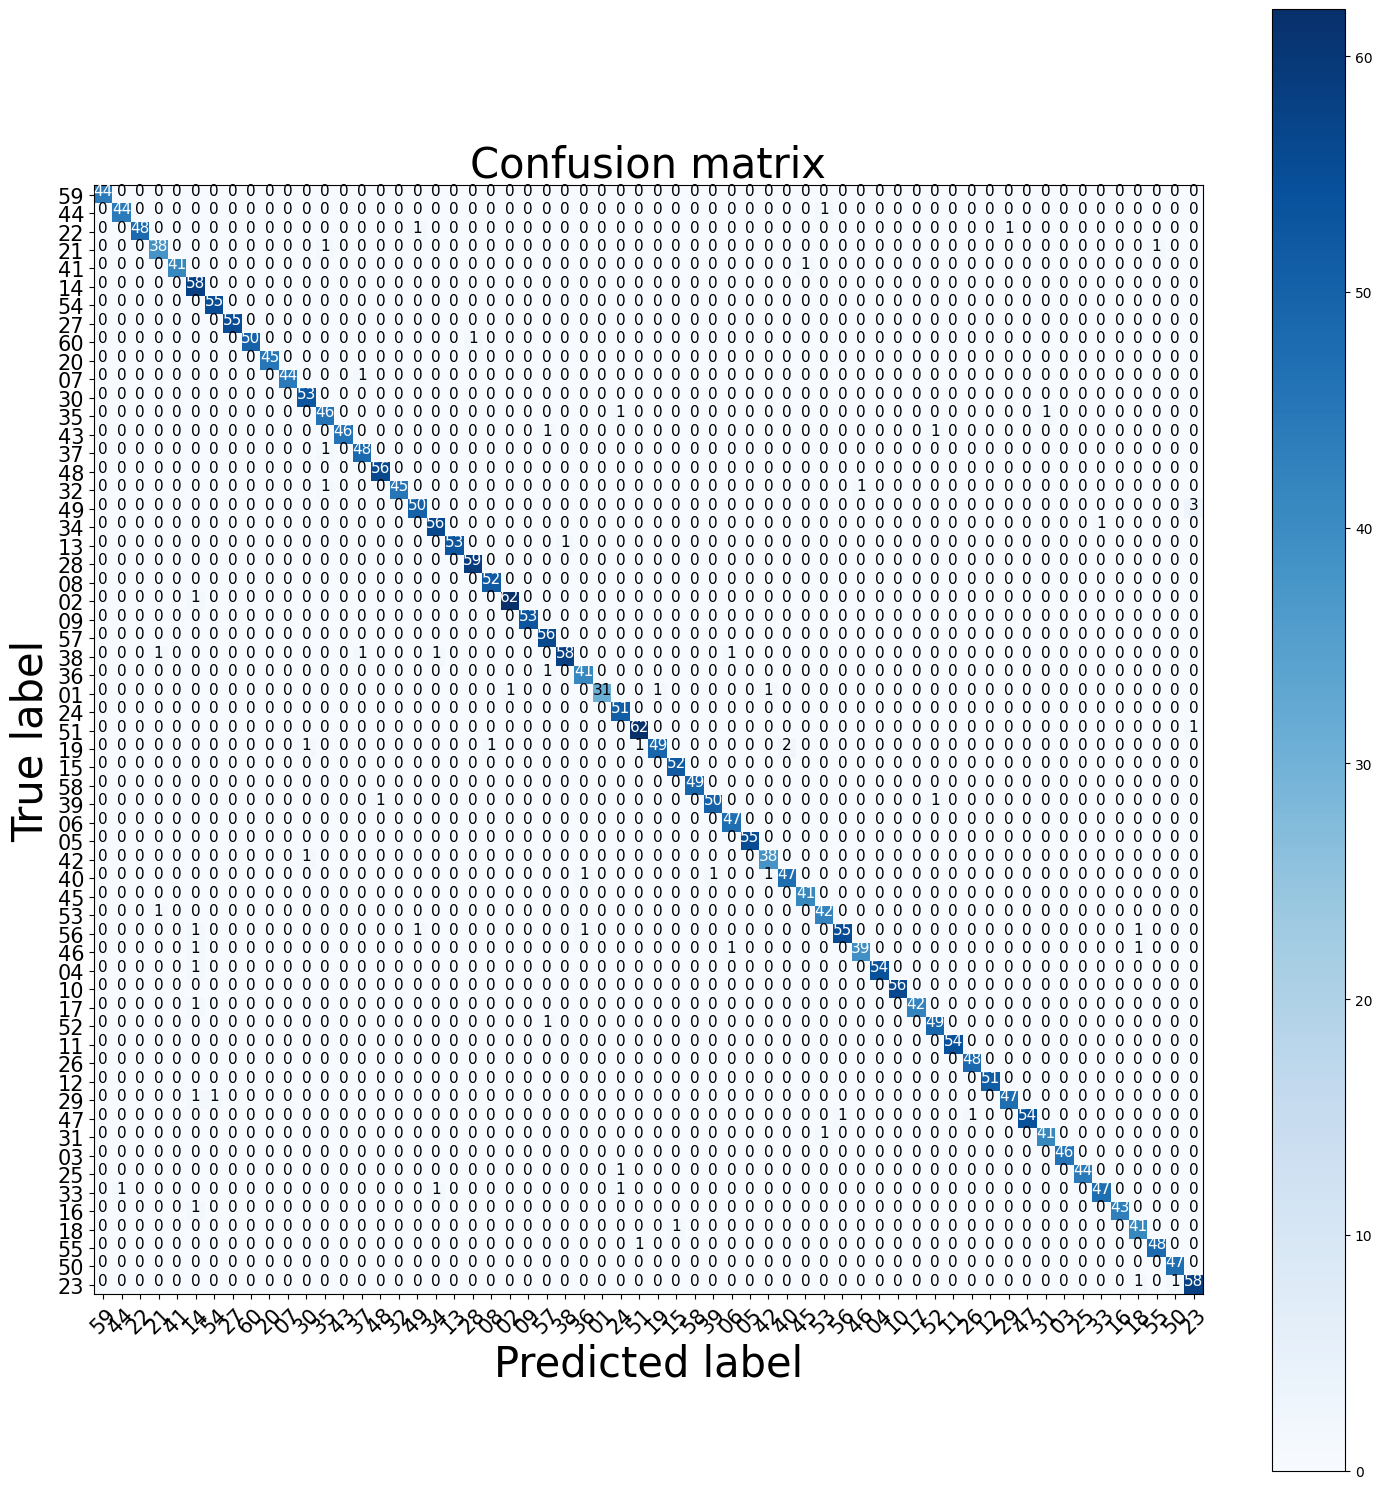

In [ ]:
from sklearn.metrics import confusion_matrix

y_predict = model.predict(mfcc_valid)
plot_confusion_matrix(confusion_matrix(labels_valid, np.argmax(y_predict,1)),labels, normalize=False)

In [ ]:
import random
index=random.randint(0,len(mfcc_valid)-1)
samples=mfcc_valid[index]
print('actual: {}'.format(labels[int(labels_valid[index])]))
print('predicted: {}'.format(labels[np.argmax(y_predict,1)[index]]))

actual: 16
predicted: 16
